# DES Y1 Mass-Richness Calibration

Compare Capish theoretical predictions against DES Y1 cluster observations.

- Survey area: 1603.5 deg²
- Richness bins: [20-30, 30-45, 45-60, 60-200] (includes highest richness bin)
- Redshift bins: [0.2-0.35, 0.35-0.5, 0.5-0.65]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pandas as pd
import sys
import os
import configparser

# Add modules to path
root_path = os.path.abspath('../')
sys.path.insert(0, root_path)
from modules.simulation import UniverseSimulator

plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Imports loaded successfully")

Imports loaded successfully


## Load DES Y1 Data

In [2]:
# Load DES Y1 RedMaPPer catalogue

# Define binning (now including the highest richness bin)
lambda_bins = np.array([20, 30, 45, 60, 200])
z_bins = np.array([0.2, 0.35, 0.5, 0.65])
lambda_cents = np.array([25.0, 37.5, 52.5, 130.0])

n_lambda_bins = len(lambda_bins) - 1
n_z_bins = len(z_bins) - 1

print(f"Richness bins: {lambda_bins}")
print(f"Redshift bins: {z_bins}")
print(f"Total calibration bins: {n_lambda_bins * n_z_bins}")

Richness bins: [ 20  30  45  60 200]
Redshift bins: [0.2  0.35 0.5  0.65]
Total calibration bins: 12


In [3]:
np.log10(134896288259.1656)

11.13

In [14]:
# Mass-richness relation parameters (from DES Y1 calibration)
MASS_RICHNESS_PARAMS = {
    'log10M_min': '11.13',
    'alpha_lambda': '-9.348',
    'beta_lambda': '0.75',
    'gamma_lambda': '0.0',
    'sigma_lambda': '0.3',
    'alpha_mwl': '0.0',
    'beta_mwl': '1.0',
    'z0' : '0.5',
    'gamma_mwl': '0.0',
    'sigma_Mwl_gal': '0.2',
    'sigma_Mwl_int': '0.05',
    'rho_0': '0.0',
    'rho_A': '0.0',
    'rho_alpha': '1.0',
    'rho_log10m0': '13'
}

# Cosmological parameters
COSMO_PARAMS = {
    'Omega_m': '0.31',
    'sigma8': '0.81',
    'Omega_b': '0.049',
    'h': '0.674',
    'ns': '0.965',
    'w0': '-1',
    'wa': '0'
}

# DES survey area
DES_AREA_DEG2 = 16000.4
DES_AREA_SR = DES_AREA_DEG2 * (np.pi/180)**2

print(f"DES survey area: {DES_AREA_DEG2} deg² ({DES_AREA_SR:.6f} sr)")
print(f"\nMass-Observable Relation Parameters:")
for key, val in MASS_RICHNESS_PARAMS.items():
    print(f"  {key} = {val}")
print(f"\nCosmological Parameters:")
for key, val in COSMO_PARAMS.items():
    print(f"  {key} = {val}")

# Create configuration dynamically for DES
def create_des_config(mr_params, cosmo_params, area_sr, richness_bins, redshift_bins):
    """Create Capish configuration for DES."""
    config = configparser.ConfigParser()
    
    # Unified parameters
    config['parameters'] = {**cosmo_params, **mr_params}
    
    # Halo catalogue
    config['halo_catalogue'] = {
        'hmf_name': 'Tinker10',
        'bias_model': 'Tinker10',
        'sky_area': str(area_sr),
        'log10m_min': '13.0',
        'log10m_max': '16.0',
        'n_mass_bins': '1500',
        'z_min': str(redshift_bins[0]),
        'z_max': str(redshift_bins[-1]),
        'n_redshift_bins': '1000',
        'mass_def_overdensity_type': 'matter',
        'mass_def_overdensity_delta': '200',
        'Mstar': '10',
        's': '0.0',
        'q': '1.0',
        'SSC': 'False',
        'Omega_c_fiducial': '0.25',
        'Omega_b_fiducial': '0.049',
        'h_fiducial': '0.674',
        'sigma_8_fiducial': '0.85',
        'n_s_fiducial': '0.965'
    }
    
    # Cluster catalogue
    config['cluster_catalogue'] = {
        'gaussian_lensing_variable': 'log10Mwl',
        'theory_sigma_Mwl_gal': 'False',
        'add_correction_to_mean_log10Mwl': 'False',
        'recompute_theory_sigma_Mwl_gal': 'False',
        'DeltaSigma_Rmin': '1',
        'DeltaSigma_Rmax': '5',
        'ngal_arcmin2': '25',
        'shape_noise': '0.3',
        'concentration_mass_relation': 'Duffy08',
        'add_completeness': 'False',
        'params_completeness': '1.0, 0.0, 14.0, 0.0',
        'add_photometric_redshift': 'False',
        'add_purity': 'False',
        'params_purity': '1.0, 0.0, 2.0, 0.0',
        'add_selection': 'False'
    }
    
    config['cluster_catalogue.mass_observable_relation'] = {
        'which_relation': 'DES'
    }
    
    config['cluster_catalogue.photometric_redshift'] = {
        'sigma_z0': '0.02'
    }
    
    # Summary statistics
    config['summary_statistics'] = {
        'summary_statistic': 'binned_count_mean_mass',
        'use_stacked_sigma_Mwl_gal': 'False',
        'use_stacked_sigma_Mwl_int': 'False',
        'Gamma': '0.7',
        'richness_edges': ','.join(map(str, richness_bins)),
        'redshift_edges': ','.join(map(str, redshift_bins))
    }
    
    return config

# Create config
config = create_des_config(MASS_RICHNESS_PARAMS, COSMO_PARAMS, DES_AREA_SR, lambda_bins, z_bins)
print("Configuration created successfully")

DES survey area: 16000.4 deg² (4.874001 sr)

Mass-Observable Relation Parameters:
  log10M_min = 11.13
  alpha_lambda = -9.348
  beta_lambda = 0.75
  gamma_lambda = 0.0
  sigma_lambda = 0.3
  alpha_mwl = 0.0
  beta_mwl = 1.0
  z0 = 0.5
  gamma_mwl = 0.0
  sigma_Mwl_gal = 0.2
  sigma_Mwl_int = 0.05
  rho_0 = 0.0
  rho_A = 0.0
  rho_alpha = 1.0
  rho_log10m0 = 13

Cosmological Parameters:
  Omega_m = 0.31
  sigma8 = 0.81
  Omega_b = 0.049
  h = 0.674
  ns = 0.965
  w0 = -1
  wa = 0
Configuration created successfully


In [15]:
# Initialize simulator with variable parameters
simulator = UniverseSimulator(
    default_config=config,
    variable_params_names=['Omega_m', 'sigma8', 'alpha_lambda', 'beta_lambda', 'gamma_lambda', 'M_min']
)

# Set fiducial parameter values
fiducial_values = [
    float(COSMO_PARAMS['Omega_m']),
    float(COSMO_PARAMS['sigma8']),
    float(MASS_RICHNESS_PARAMS['alpha_lambda']),
    float(MASS_RICHNESS_PARAMS['beta_lambda']),
    float(MASS_RICHNESS_PARAMS['gamma_lambda']),
    float(MASS_RICHNESS_PARAMS['log10M_min'])
]

print("="*70)
print("SIMULATION PARAMETERS")
print("="*70)
print("\nFiducial parameter values:")
print(f"  Omega_m = {fiducial_values[0]}")
print(f"  sigma8 = {fiducial_values[1]}")
print(f"  alpha_lambda = {fiducial_values[2]}")
print(f"  beta_lambda = {fiducial_values[3]}")
print(f"  gamma_lambda = {fiducial_values[4]}")
print(f"  M_min = {fiducial_values[5]:.3e}")

print("\nAll Parameters (from simulator.params_values):")
for key, val in simulator.params_values.items():
    if key == 'm_min':
        print(f"  {key:16s} = {val:.3e} M☉ (log10 = {np.log10(val):.3f})")
    else:
        print(f"  {key:16s} = {val}")

print("\nSurvey Configuration:")
print(f"  Sky area         = {simulator.halo_catalogue_class.sky_area:.6f} sr ({simulator.halo_catalogue_class.sky_area * (180/np.pi)**2:.1f} deg²)")
print(f"  Mass function    = {simulator.halo_catalogue_class.hmf}")
print(f"  Mass definition  = {simulator.halo_catalogue_class.mass_definition}")
print(f"  λ bins           = {lambda_bins}")
print(f"  z bins           = {z_bins}")
print("="*70)

# Run simulation
print("\nRunning simulation...")
summary_stats = simulator.run_simulation(fiducial_values)
print("Simulation complete!")

SIMULATION PARAMETERS

Fiducial parameter values:
  Omega_m = 0.31
  sigma8 = 0.81
  alpha_lambda = -9.348
  beta_lambda = 0.75
  gamma_lambda = 0.0
  M_min = 1.113e+01

All Parameters (from simulator.params_values):
  omega_m          = 0.31
  sigma8           = 0.81
  omega_b          = 0.049
  h                = 0.674
  ns               = 0.965
  w0               = -1.0
  wa               = 0.0
  log10m_min       = 11.13
  alpha_lambda     = -9.348
  beta_lambda      = 0.75
  gamma_lambda     = 0.0
  sigma_lambda     = 0.3
  alpha_mwl        = 0.0
  beta_mwl         = 1.0
  z0               = 0.5
  gamma_mwl        = 0.0
  sigma_mwl_gal    = 0.2
  sigma_mwl_int    = 0.05
  rho_0            = 0.0
  rho_a            = 0.0
  rho_alpha        = 1.0
  rho_log10m0      = 13.0

Survey Configuration:
  Sky area         = 4.874001 sr (16000.4 deg²)
  Mass function    = <pyccl.halos.hmfunc.tinker10.MassFuncTinker10>
	mass_def = MassDef(Delta=200, rho_type=matter)
  Mass definition  = MassDef(

In [16]:
4*np.pi/8

1.5707963267948966

In [17]:
simulator.halo_catalogue_class.mass_definition

MassDef(Delta=200, rho_type=matter)

In [18]:
simulator.halo_catalogue_class.hmf

<pyccl.halos.hmfunc.tinker10.MassFuncTinker10>
	mass_def = MassDef(Delta=200, rho_type=matter)

In [19]:
def summary_statistic_to_sensible_format(summary_statistic, n_z=3, n_lambda=4):
    """Format Capish results - now returns tuple (count_stat, mass_stat)."""
    
    if isinstance(summary_statistic, tuple) and len(summary_statistic) == 2:
        # New format: tuple of (counts, masses) 
        count_stat, mass_stat = summary_statistic
        sim_n_clusters = np.array(count_stat)
        sim_mwl_mean = np.array(mass_stat)
        
        # Check if we need to transpose - Capish returns (n_lambda, n_z) but we want (n_z, n_lambda)
        if sim_n_clusters.shape == (n_lambda, n_z):
            sim_n_clusters = sim_n_clusters.T
            sim_mwl_mean = sim_mwl_mean.T
            
    else:
        # Old format: flat array
        n_total_bins = n_z * n_lambda
        sim_n_clusters = summary_statistic[:n_total_bins].reshape(n_z, n_lambda)
        sim_mwl_mean = summary_statistic[n_total_bins:].reshape(n_z, n_lambda)
    
    return sim_n_clusters, sim_mwl_mean

# Format the Capish results
capish_counts, capish_masses = summary_statistic_to_sensible_format(summary_stats, n_z_bins, n_lambda_bins)

print(f"Summary stats type: {type(summary_stats)}")
if isinstance(summary_stats, tuple):
    print(f"Tuple length: {len(summary_stats)}")
    for i, item in enumerate(summary_stats):
        print(f"  Item {i}: type={type(item)}, shape={getattr(item, 'shape', 'N/A')}")

print(f"Raw Capish results shape: {summary_stats[0].shape}")
print(f"Capish counts shape after formatting: {capish_counts.shape}")
print(f"Capish masses shape after formatting: {capish_masses.shape}")
print(f"\nCapish counts:")
print(capish_counts)
print(f"\nCapish masses:")
print(capish_masses)

Summary stats type: <class 'tuple'>
Tuple length: 2
  Item 0: type=<class 'numpy.ndarray'>, shape=(4, 3)
  Item 1: type=<class 'numpy.ndarray'>, shape=(4, 3)
Raw Capish results shape: (4, 3)
Capish counts shape after formatting: (3, 4)
Capish masses shape after formatting: (3, 4)

Capish counts:
[[21241.  8308.  2410.  1450.]
 [35191. 12656.  3266.  1892.]
 [43686. 14371.  3334.  1721.]]

Capish masses:
[[14.14164041 14.38741073 14.60250152 14.82672448]
 [14.11864109 14.36599691 14.57151499 14.79173826]
 [14.09465404 14.33471547 14.55304896 14.76994421]]


## Tutorial-Style Comparison Plot

## Parameter Iteration

Modify `MASS_RICHNESS_PARAMS` above and re-run cells to calibrate parameters.

## Catalog Diagnostics

In [20]:
# Generate halo and cluster catalogs using existing methods
log10m_true, z_true = simulator.run_simulation_halo_catalogue(fiducial_values)
richness, log10mWL, z_obs = simulator.run_simulation_cluster_catalogue(fiducial_values)

print(f"Generated {len(log10m_true)} halos")
print(f"Generated {len(richness)} clusters")
print(f"Halo mass range: {np.min(log10m_true):.2f} - {np.max(log10m_true):.2f}")
print(f"Cluster richness range: {np.min(richness):.1f} - {np.max(richness):.1f}")
print(f"Cluster redshift range: {np.min(z_obs):.3f} - {np.max(z_obs):.3f}")

Generated 4558731 halos
Generated 4555947 clusters
Halo mass range: 13.00 - 15.66
Cluster richness range: 0.1 - 266.1
Cluster redshift range: 0.200 - 0.650


In [21]:
# Reproducibility (affects halo Poisson draws and richness scatter)
np.random.seed(12345)

# Use the exact same survey configuration for halos and clusters
config_match = simulator.new_config_files(fiducial_values)

halo_data = simulator.halo_catalogue_class.get_halo_catalogue(config_match)
log10m_halo = halo_data['log10mass']
z_halo = halo_data['redshift']

# Generate cluster observables from the *same* halo catalogue
richness_match, log10mWL_match, z_obs_match = simulator.cluster_catalogue_class.get_cluster_catalogue(
    log10m_halo, z_halo, config_match
)

# Simple catalogue containers (swap to DataFrame/Table if you prefer)
halo_catalogue = {
    'log10m_true': log10m_halo,
    'z_true': z_halo,
}

cluster_catalogue = {
    'log10m_true': log10m_halo,
    'z_true': z_halo,
    'richness': richness_match,
    'log10m_wl': log10mWL_match,
    'z_obs': z_obs_match,
}

print(f"Halo catalogue size: {len(log10m_halo)}")
print(f"Cluster catalogue size: {len(richness_match)} (one per halo before any cuts)")


Halo catalogue size: 4566000
Cluster catalogue size: 4566000 (one per halo before any cuts)


In [22]:
params = {
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "text.usetex": True,
    "figure.figsize": [3.386, 3.386],
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
}
plt.rcParams.update(params)

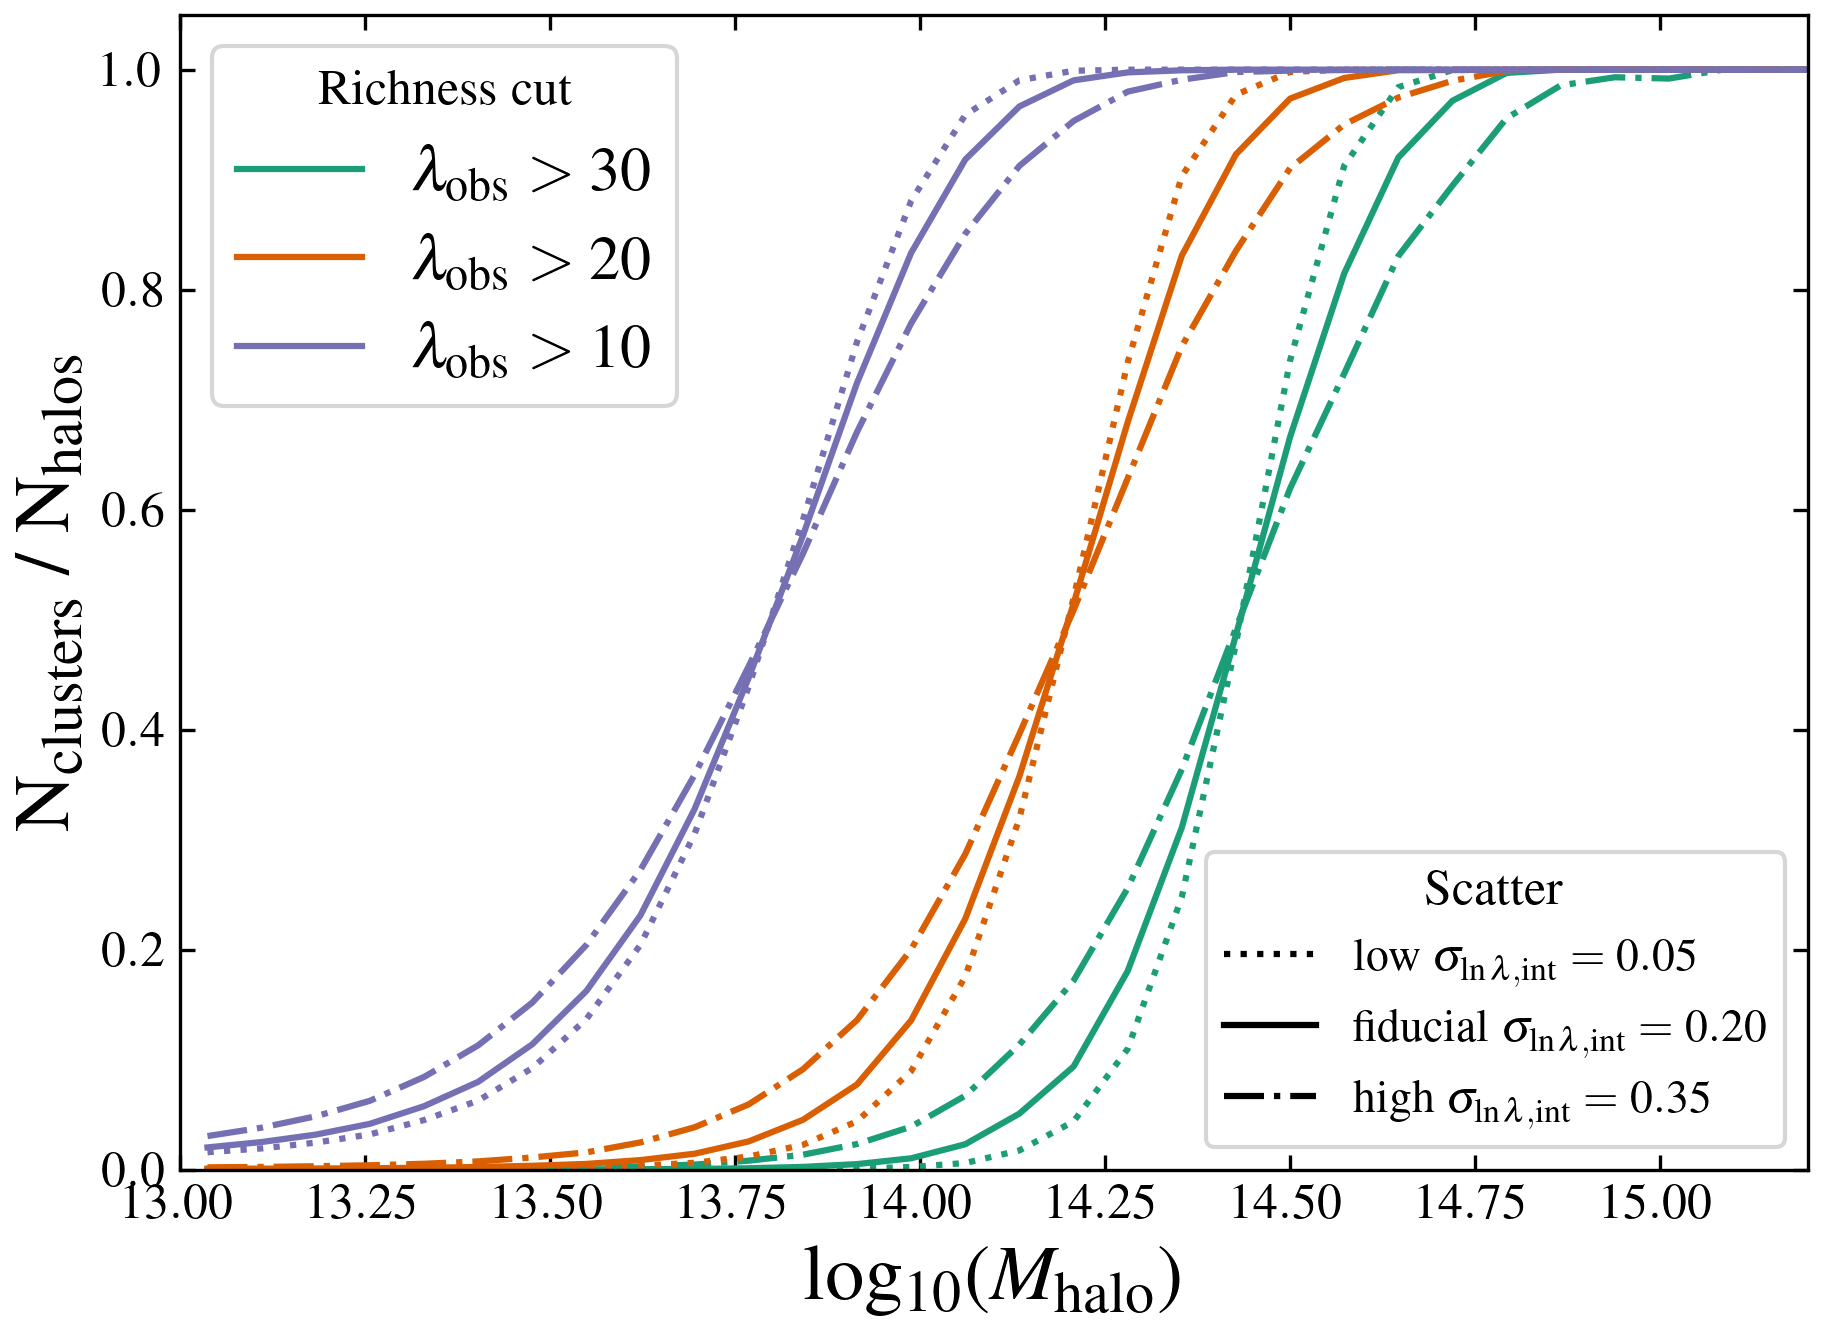

In [56]:
fig, ax = plt.subplots(figsize=(7, 5))

# --- Completeness vs halo mass with richness cuts and scatter variants ---
richness_cuts = [30.0, 20.0, 10.0]  # change thresholds here

log10m_min = float(config_match['halo_catalogue']['log10m_min'])
log10m_max = float(config_match['halo_catalogue']['log10m_max'])
mass_bins = np.linspace(log10m_min, log10m_max, 42)
mass_centers = 0.5 * (mass_bins[:-1] + mass_bins[1:])

# Set scatter values (edit as needed)
sigma_lambda_fid = 0.2
sigma_lambda_low = 0.05
sigma_lambda_high = 0.35

scatter_configs = {
    'low': sigma_lambda_low,
    'fid': sigma_lambda_fid,
    'high': sigma_lambda_high,
}
linestyles = {
    'low': ':',
    'fid': '-',
    'high': '-.',  # dense dots
}

# Generate richness for each scatter using the same halo catalogue
richness_by_scatter = {}
for key, sigma_lambda in scatter_configs.items():
    config_scatter = simulator.new_config_files(fiducial_values)
    config_scatter['parameters']['sigma_lambda'] = str(sigma_lambda)

    np.random.seed(12345)
    richness_scatter, _, _ = simulator.cluster_catalogue_class.get_cluster_catalogue(
        log10m_halo, z_halo, config_scatter
    )
    richness_by_scatter[key] = richness_scatter

def completeness_curve(richness_array, richness_cut, mass_bins):
    halo_counts, _ = np.histogram(log10m_halo, bins=mass_bins)
    cluster_counts, _ = np.histogram(log10m_halo[richness_array >= richness_cut], bins=mass_bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        completeness = np.where(halo_counts > 0, cluster_counts / halo_counts, np.nan)
    return completeness

colors = plt.cm.Dark2.colors
for i, cut in enumerate(richness_cuts):
    color = colors[i % len(colors)]
    for key, sigma_lambda in scatter_configs.items():
        comp = completeness_curve(richness_by_scatter[key], cut, mass_bins)
        ax.plot(mass_centers, comp, color=color, linestyle=linestyles[key])

# Legends: richness cuts (colors) and scatter (linestyles)
from matplotlib.lines import Line2D
richness_handles = [
    Line2D([0], [0], color=colors[i % len(colors)], linestyle='-',
           label=r'$\lambda_{\rm obs}$ '+rf'$>{cut:g}$')
    for i, cut in enumerate(richness_cuts)
]
scatter_handles = [
    Line2D([0], [0], color='k', linestyle=linestyles['low'],
           label=r'low $\sigma_{\ln\lambda, \mathrm{int}}= $' + rf' ${sigma_lambda_low:.2f}$'),
    Line2D([0], [0], color='k', linestyle=linestyles['fid'],
           label=r'fiducial $\sigma_{\ln\lambda, \mathrm{int}}= $' + rf' ${sigma_lambda_fid:.2f}$'),
    Line2D([0], [0], color='k', linestyle=linestyles['high'],
           label=r'high $\sigma_{\ln\lambda, \mathrm{int}}= $' + rf' ${sigma_lambda_high:.2f}$'),
]
leg1 = ax.legend(handles=richness_handles, title='Richness cut', fontsize=15, loc='upper left')
ax.add_artist(leg1)
ax.legend(handles=scatter_handles, title='Scatter', fontsize=11, loc='lower right')

ax.set_xlim(13, 15.2)
ax.set_ylim(0, 1.05)
ax.set_xlabel(r'log$_{10}$($M_{\rm{halo}}$)', fontsize=19)
ax.set_ylabel(r'N$_{\rm{clusters}}$ / N$_{\rm{halos}}$', fontsize=19)
plt.savefig('completeness.png', dpi = 300, bbox_inches='tight',)